# ML PROJECT 2
# CLASSIFICATION DATASET: AIRLINE PASSENGER SATISFACTION DATASET

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV 
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
--- DATA LOAD ---

In [2]:
df=pd.read_csv("C:/Users/YUKESH/Downloads/Airline_Passenger_Satisfaction_Dataset.csv")
df

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,Female,Loyal Customer,52,Business travel,Eco,160,5,4,3,4,...,5,5,5,5,2,5,5,50,44.0,satisfied
1,Female,Loyal Customer,36,Business travel,Business,2863,1,1,3,1,...,4,4,4,4,3,4,5,0,0.0,satisfied
2,Male,disloyal Customer,20,Business travel,Eco,192,2,0,2,4,...,2,4,1,3,2,2,2,0,0.0,neutral or dissatisfied
3,Male,Loyal Customer,44,Business travel,Business,3377,0,0,0,2,...,1,1,1,1,3,1,4,0,6.0,satisfied
4,Female,Loyal Customer,49,Business travel,Eco,1182,2,3,4,3,...,2,2,2,2,4,2,4,0,20.0,satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25971,Male,disloyal Customer,34,Business travel,Business,526,3,3,3,1,...,4,3,2,4,4,5,4,0,0.0,neutral or dissatisfied
25972,Male,Loyal Customer,23,Business travel,Business,646,4,4,4,4,...,4,4,5,5,5,5,4,0,0.0,satisfied
25973,Female,Loyal Customer,17,Personal Travel,Eco,828,2,5,1,5,...,2,4,3,4,5,4,2,0,0.0,neutral or dissatisfied
25974,Male,Loyal Customer,14,Business travel,Business,1127,3,3,3,3,...,4,3,2,5,4,5,4,0,0.0,satisfied


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25976 entries, 0 to 25975
Data columns (total 23 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Gender                             25976 non-null  object 
 1   Customer Type                      25976 non-null  object 
 2   Age                                25976 non-null  int64  
 3   Type of Travel                     25976 non-null  object 
 4   Class                              25976 non-null  object 
 5   Flight Distance                    25976 non-null  int64  
 6   Inflight wifi service              25976 non-null  int64  
 7   Departure/Arrival time convenient  25976 non-null  int64  
 8   Ease of Online booking             25976 non-null  int64  
 9   Gate location                      25976 non-null  int64  
 10  Food and drink                     25976 non-null  int64  
 11  Online boarding                    25976 non-null  int

In [4]:
df.corr(numeric_only=True)

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
Age,1.000000,0.099409,0.009242,0.032449,0.013565,0.003308,0.023841,0.202058,0.154507,0.068998,0.054977,0.033299,-0.049863,0.025388,-0.059083,0.048418,-0.004334,-0.007400
Flight Distance,0.099409,1.000000,0.005007,-0.014401,0.062989,0.008410,0.057322,0.214629,0.158957,0.137538,0.117880,0.136995,0.071549,0.075720,0.066355,0.105578,0.003446,0.000131
Inflight wifi service,0.009242,0.005007,1.000000,0.349137,0.710684,0.347790,0.122306,0.459366,0.116991,0.201782,0.113658,0.159699,0.118199,0.046046,0.108419,0.125768,-0.010078,-0.012277
Departure/Arrival time convenient,0.032449,-0.014401,0.349137,1.000000,0.440230,0.458439,-0.016006,0.080937,-0.001926,-0.022326,0.060982,0.003373,0.065684,0.082461,0.067804,-0.007670,-0.000238,-0.001345
Ease of Online booking,0.013565,0.062989,0.710684,0.440230,1.000000,0.465514,0.025141,0.408003,0.022811,0.044715,0.039988,0.116754,0.040685,-0.000108,0.035769,0.010974,-0.001062,-0.003161
Gate location,0.003308,0.008410,0.347790,0.458439,0.465514,1.000000,-0.009694,0.006993,-0.000721,-0.000340,-0.031606,-0.002428,-0.004395,-0.054954,-0.005129,-0.014195,0.008039,0.007776
Food and drink,0.023841,0.057322,0.122306,-0.016006,0.025141,-0.009694,1.000000,0.229601,0.580970,0.627265,0.050688,0.035870,0.037617,0.076775,0.039992,0.659253,-0.025957,-0.028309
Online boarding,0.202058,0.214629,0.459366,0.080937,0.408003,0.006993,0.229601,1.000000,0.415414,0.279391,0.149430,0.120354,0.084583,0.203309,0.071972,0.320912,-0.021037,-0.025875
Seat comfort,0.154507,0.158957,0.116991,-0.001926,0.022811,-0.000721,0.580970,0.415414,1.000000,0.616817,0.124805,0.099150,0.074927,0.182469,0.067306,0.683924,-0.028341,-0.033030
Inflight entertainment,0.068998,0.137538,0.201782,-0.022326,0.044715,-0.000340,0.627265,0.279391,0.616817,1.000000,0.412266,0.303203,0.382782,0.114343,0.411018,0.695269,-0.025085,-0.028314


In [5]:
import pandas as pd
from scipy.stats import chi2_contingency

table = pd.crosstab(df['Gender'], df['satisfaction'])


chi2_stat, p_val, dof, expected = chi2_contingency(table)
print( chi2_stat)
print(p_val)

if p_val < 0.05:
    print("yes")  # Reject the null hypothesis(accpeting alternative)
else:
    print("no")  # Fail to reject the null hypothesis

1.368158705041111
0.24212849570930395
no


In [6]:
import pandas as pd
from scipy.stats import chi2_contingency

table = pd.crosstab(df['Customer Type'], df['satisfaction'])


chi2_stat, p_val, dof, expected = chi2_contingency(table)
print( chi2_stat)
print(p_val)

if p_val < 0.05:
    print("yes")  # Reject the null hypothesis(accpeting alternative)
else:
    print("no")  # Fail to reject the null hypothesis

837.2511339794698
4.2975534526069954e-184
yes


In [7]:
import pandas as pd
from scipy.stats import chi2_contingency

table = pd.crosstab(df['Type of Travel'], df['satisfaction'])


chi2_stat, p_val, dof, expected = chi2_contingency(table)
print( chi2_stat)
print(p_val)

if p_val < 0.05:
    print("yes")  # Reject the null hypothesis(accpeting alternative)
else:
    print("no")  # Fail to reject the null hypothesis

5334.846279468312
0.0
yes


In [8]:
import pandas as pd
from scipy.stats import chi2_contingency

table = pd.crosstab(df['Class'], df['satisfaction'])


chi2_stat, p_val, dof, expected = chi2_contingency(table)
print( chi2_stat)
print(p_val)

if p_val < 0.05:
    print("yes")  # Reject the null hypothesis(accpeting alternative)
else:
    print("no")  # Fail to reject the null hypothesis

6435.0352328191975
0.0
yes


In [9]:
df=df.drop("Gender",axis=1)
df

,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,Loyal Customer,52,Business travel,Eco,160,5,4,3,4,3,...,5,5,5,5,2,5,5,50,44.0,satisfied
1,Loyal Customer,36,Business travel,Business,2863,1,1,3,1,5,...,4,4,4,4,3,4,5,0,0.0,satisfied
2,disloyal Customer,20,Business travel,Eco,192,2,0,2,4,2,...,2,4,1,3,2,2,2,0,0.0,neutral or dissatisfied
3,Loyal Customer,44,Business travel,Business,3377,0,0,0,2,3,...,1,1,1,1,3,1,4,0,6.0,satisfied
4,Loyal Customer,49,Business travel,Eco,1182,2,3,4,3,4,...,2,2,2,2,4,2,4,0,20.0,satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25971,disloyal Customer,34,Business travel,Business,526,3,3,3,1,4,...,4,3,2,4,4,5,4,0,0.0,neutral or dissatisfied
25972,Loyal Customer,23,Business travel,Business,646,4,4,4,4,4,...,4,4,5,5,5,5,4,0,0.0,satisfied
25973,Loyal Customer,17,Personal Travel,Eco,828,2,5,1,5,2,...,2,4,3,4,5,4,2,0,0.0,neutral or dissatisfied
25974,Loyal Customer,14,Business travel,Business,1127,3,3,3,3,4,...,4,3,2,5,4,5,4,0,0.0,satisfied


In [ ]:
--- ENCODING ---

In [10]:
encode=LabelEncoder()
df["Customer Type"]=encode.fit_transform(df["Customer Type"])
df["Type of Travel"]=encode.fit_transform(df["Type of Travel"])
df["Class"]=encode.fit_transform(df["Class"])
df["satisfaction"]=encode.fit_transform(df["satisfaction"])

In [ ]:
--- HANDLING NULL VALUES ---

In [11]:
df.isnull().sum()

Customer Type                         0
Age                                   0
Type of Travel                        0
Class                                 0
Flight Distance                       0
Inflight wifi service                 0
Departure/Arrival time convenient     0
Ease of Online booking                0
Gate location                         0
Food and drink                        0
Online boarding                       0
Seat comfort                          0
Inflight entertainment                0
On-board service                      0
Leg room service                      0
Baggage handling                      0
Checkin service                       0
Inflight service                      0
Cleanliness                           0
Departure Delay in Minutes            0
Arrival Delay in Minutes             83
satisfaction                          0
dtype: int64

In [12]:
df["Arrival Delay in Minutes"]=df["Arrival Delay in Minutes"].fillna(df.groupby("satisfaction")["Arrival Delay in Minutes"].transform("mean"))

In [13]:
df.isnull().sum()

Customer Type                        0
Age                                  0
Type of Travel                       0
Class                                0
Flight Distance                      0
Inflight wifi service                0
Departure/Arrival time convenient    0
Ease of Online booking               0
Gate location                        0
Food and drink                       0
Online boarding                      0
Seat comfort                         0
Inflight entertainment               0
On-board service                     0
Leg room service                     0
Baggage handling                     0
Checkin service                      0
Inflight service                     0
Cleanliness                          0
Departure Delay in Minutes           0
Arrival Delay in Minutes             0
satisfaction                         0
dtype: int64

In [ ]:
--- CHECKING OUTLIERS ---

<Axes: xlabel='Flight Distance'>

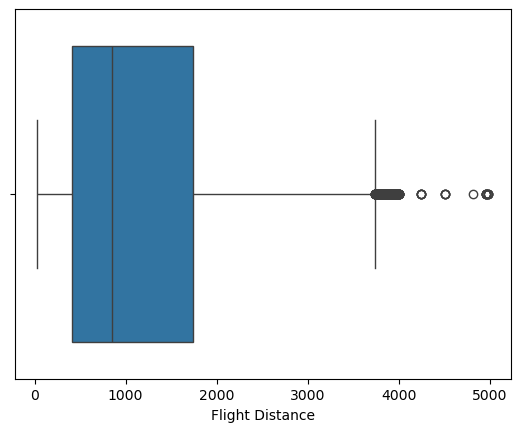

In [14]:
sns.boxplot(x="Flight Distance",data=df)

<Axes: xlabel='Inflight wifi service'>

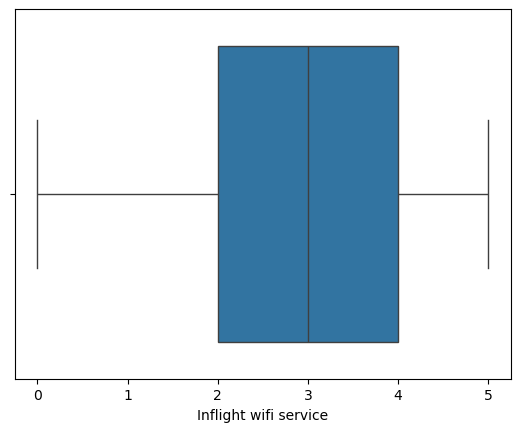

In [15]:
sns.boxplot(x="Inflight wifi service",data=df)

<Axes: xlabel='Departure/Arrival time convenient'>

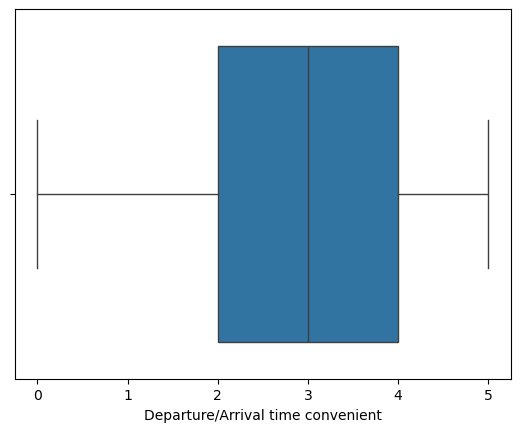

In [16]:
sns.boxplot(x="Departure/Arrival time convenient",data=df)

<Axes: xlabel='Ease of Online booking'>

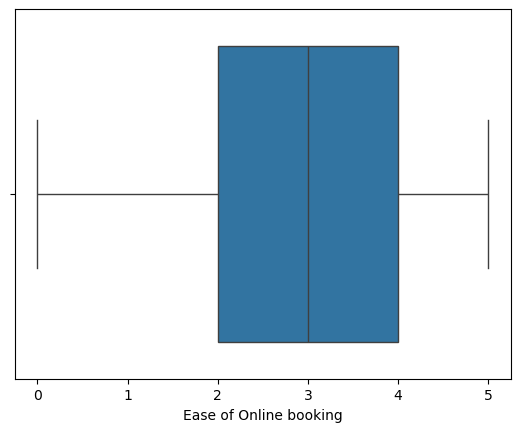

In [17]:
sns.boxplot(x="Ease of Online booking",data=df)

<Axes: xlabel='Gate location'>

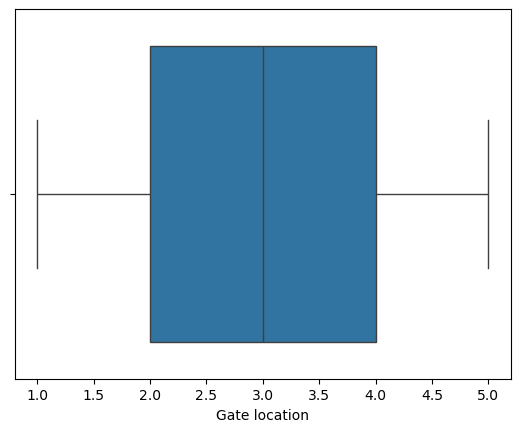

In [18]:
sns.boxplot(x="Gate location",data=df)

<Axes: xlabel='Food and drink'>

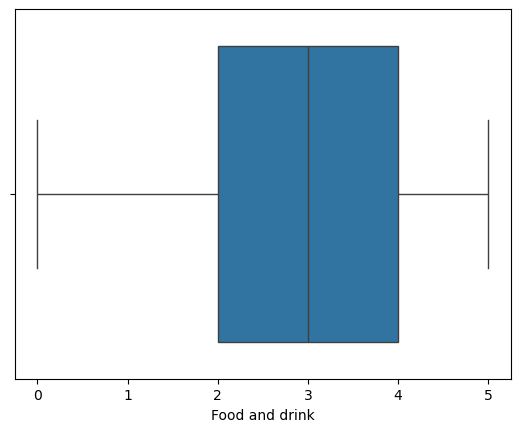

In [19]:
sns.boxplot(x="Food and drink",data=df)

<Axes: xlabel='Online boarding'>

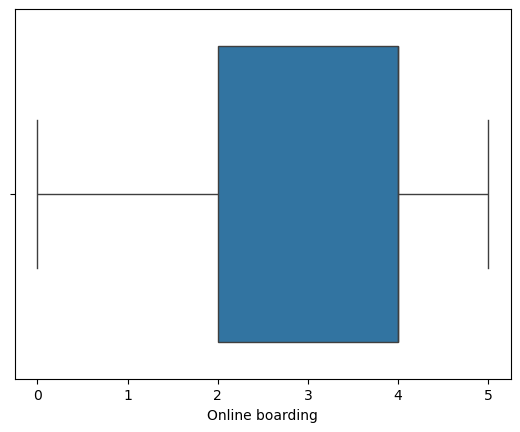

In [20]:
sns.boxplot(x="Online boarding",data=df)

<Axes: xlabel='Seat comfort'>

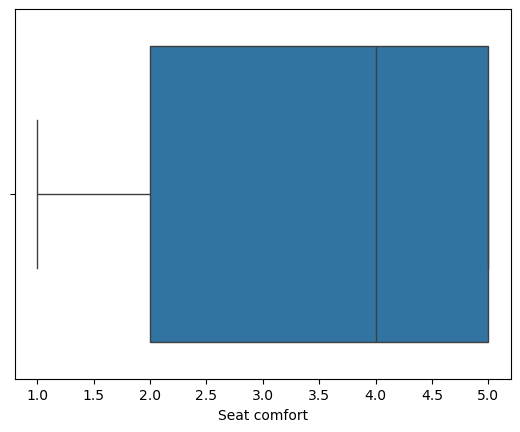

In [21]:
sns.boxplot(x="Seat comfort",data=df)

<Axes: xlabel='Inflight entertainment'>

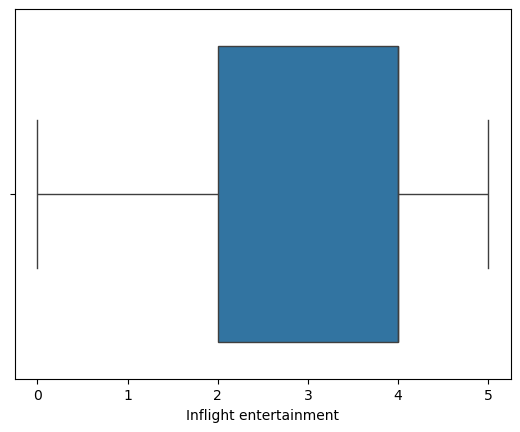

In [22]:
sns.boxplot(x="Inflight entertainment",data=df)

<Axes: xlabel='On-board service'>

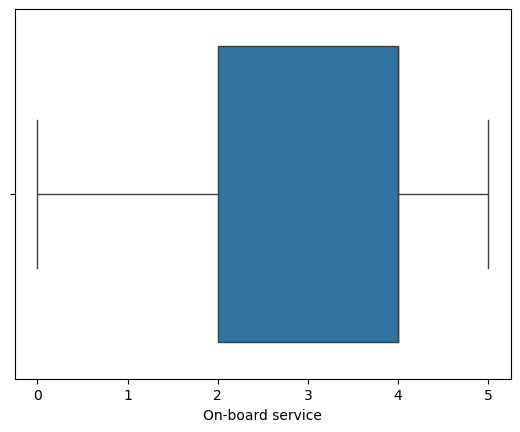

In [23]:
sns.boxplot(x="On-board service",data=df)

<Axes: xlabel='Leg room service'>

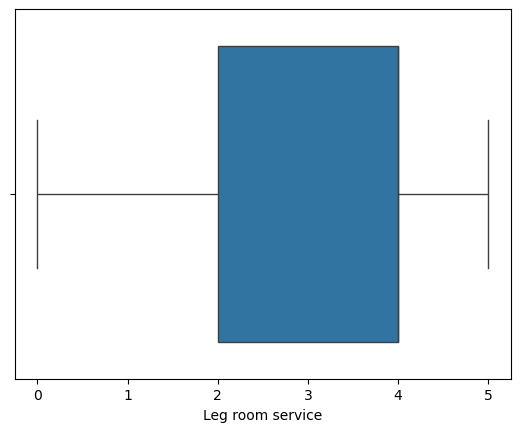

In [24]:
sns.boxplot(x="Leg room service",data=df)

<Axes: xlabel='Baggage handling'>

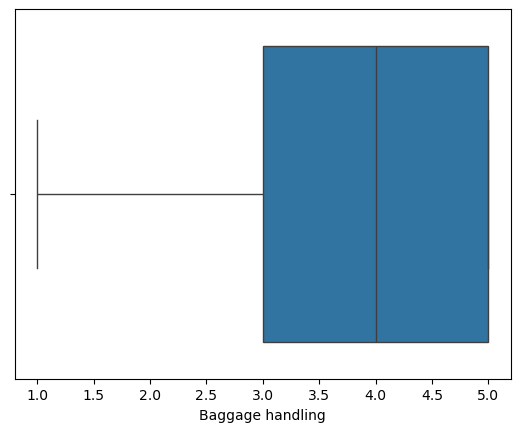

In [25]:
sns.boxplot(x="Baggage handling",data=df)

<Axes: xlabel='Checkin service'>

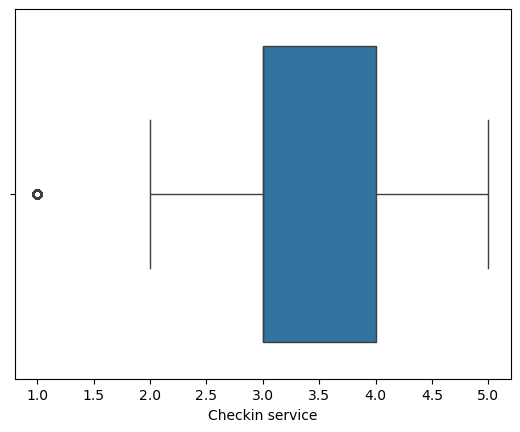

In [26]:
sns.boxplot(x="Checkin service",data=df)

<Axes: xlabel='Inflight service'>

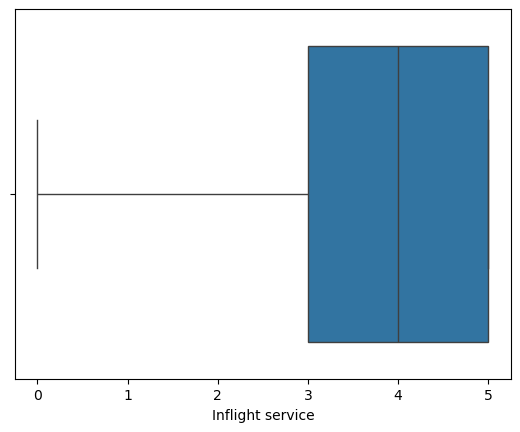

In [27]:
sns.boxplot(x="Inflight service",data=df)

<Axes: xlabel='Cleanliness'>

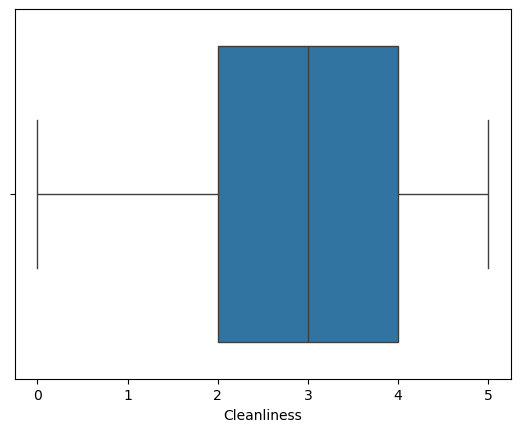

In [28]:
sns.boxplot(x="Cleanliness",data=df)

<Axes: xlabel='Departure Delay in Minutes'>

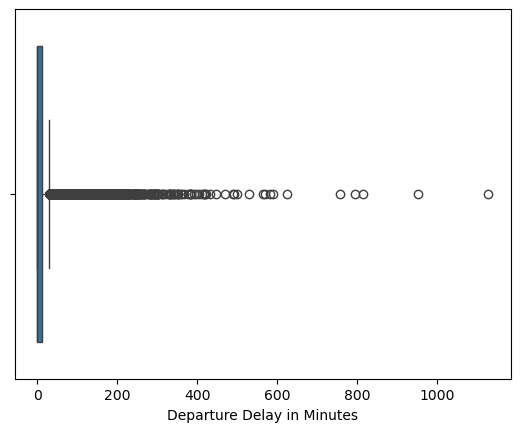

In [29]:
sns.boxplot(x="Departure Delay in Minutes",data=df)

<Axes: xlabel='Arrival Delay in Minutes'>

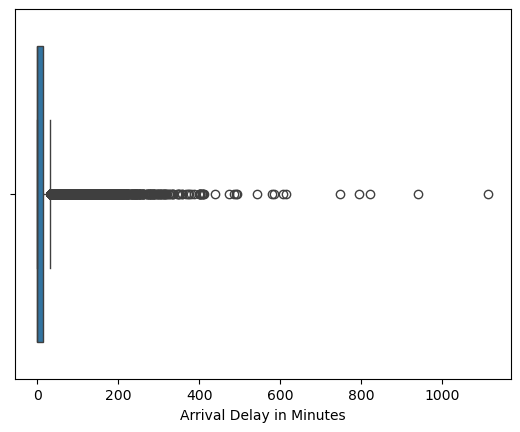

In [30]:
sns.boxplot(x="Arrival Delay in Minutes",data=df)

In [ ]:
--- SPLITING Y AND X ---

In [31]:
y=df["satisfaction"]
y

0        1
1        1
2        0
3        1
4        1
        ..
25971    0
25972    1
25973    0
25974    1
25975    0
Name: satisfaction, Length: 25976, dtype: int64

In [32]:
x=df.drop("satisfaction",axis=1)
x

,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
0,0,52,0,1,160,5,4,3,4,3,...,3,5,5,5,5,2,5,5,50,44.0
1,0,36,0,0,2863,1,1,3,1,5,...,5,4,4,4,4,3,4,5,0,0.0
2,1,20,0,1,192,2,0,2,4,2,...,2,2,4,1,3,2,2,2,0,0.0
3,0,44,0,0,3377,0,0,0,2,3,...,4,1,1,1,1,3,1,4,0,6.0
4,0,49,0,1,1182,2,3,4,3,4,...,2,2,2,2,2,4,2,4,0,20.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25971,1,34,0,0,526,3,3,3,1,4,...,4,4,3,2,4,4,5,4,0,0.0
25972,0,23,0,0,646,4,4,4,4,4,...,4,4,4,5,5,5,5,4,0,0.0
25973,0,17,1,1,828,2,5,1,5,2,...,2,2,4,3,4,5,4,2,0,0.0
25974,0,14,0,0,1127,3,3,3,3,4,...,4,4,3,2,5,4,5,4,0,0.0


In [ ]:
--- TRAINING PROCESS ---

In [33]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
--- HADALING IMBALANCE DATA ---

In [34]:
y_train.value_counts()

satisfaction
0    11628
1     9152
Name: count, dtype: int64

In [35]:
smote = SMOTE(sampling_strategy='minority')
x_sm, y_sm = smote.fit_resample(x_train, y_train)
y_sm.value_counts()

satisfaction
1    11628
0    11628
Name: count, dtype: int64

In [ ]:
--- SCALING --

In [36]:
scale=StandardScaler()
x_train_scaled=scale.fit_transform(x_train)
x_test_scaled=scale.transform(x_test)

In [ ]:
--- MODEL 1 ---
--- LOGISTIC REGRESSION ---

In [37]:
model1=LogisticRegression()
model1.fit(x_train,y_train)

C:\Users\YUKESH\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [38]:
# test_accurarcy
y_pred1=model1.predict(x_test)
accuracy1=accuracy_score(y_test,y_pred1)
accuracy1

0.8098537336412626

In [39]:
# training _accuracy 
y_train_pred1=model1.predict(x_train)
final_training1=accuracy_score(y_train_pred1,y_train)
final_training1

0.8181424446583253

In [40]:
# classification_report
cr1 = classification_report(y_test, y_pred1, target_names=["Satisfied as 0", "Neutral or Dissatisfied as 1"])
print("\nLogistic Regression:")
print("\nClassification Report:")
print(cr1)


Logistic Regression:

Classification Report:
                              precision    recall  f1-score   support

              Satisfied as 0       0.85      0.81      0.83      2945
Neutral or Dissatisfied as 1       0.76      0.81      0.79      2251

                    accuracy                           0.81      5196
                   macro avg       0.81      0.81      0.81      5196
                weighted avg       0.81      0.81      0.81      5196



In [ ]:
--- MODEL 2 ---
--- KNN [K NEAREST NEIGHBORS CLASSIFIER] ---

In [41]:
model2=KNeighborsClassifier()
model2.fit(x_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [42]:
# testing_accuracy
y_pred2=model2.predict(x_test)
accuracy2=accuracy_score(y_test,y_pred2)
accuracy2

0.6930331023864511

In [43]:
# training _accuracy 
y_train_pred2=model2.predict(x_train)
final_training2=accuracy_score(y_train_pred2,y_train)
final_training2

0.8046679499518768

In [44]:
# clssification_report
cr2 = classification_report(y_test, y_pred2, target_names=["Satisfied as 0", "Neutral or Dissatisfied as 1"])
print("\nK Nearest Neighbors:")
print("\nClassification Report:")
print(cr2)


K Nearest Neighbors:

Classification Report:
                              precision    recall  f1-score   support

              Satisfied as 0       0.72      0.75      0.73      2945
Neutral or Dissatisfied as 1       0.65      0.62      0.64      2251

                    accuracy                           0.69      5196
                   macro avg       0.69      0.68      0.69      5196
                weighted avg       0.69      0.69      0.69      5196



In [45]:
# hyper parameter
model_2=KNeighborsClassifier()

parameter = {'n_neighbors': [3,5,7], 'metric': ['euclidean', 'manhattan'] }

random = RandomizedSearchCV( estimator=model_2, param_distributions=parameter, cv=5, scoring='accuracy' )

random.fit(x_train,y_train)

print("Best parameters:", random.best_params_)

print("Best CV score:", random.best_score_)

C:\Users\YUKESH\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best parameters: {'n_neighbors': 7, 'metric': 'manhattan'}
Best CV score: 0.7757459095283927


In [46]:
# Applying best parameter
model_2=KNeighborsClassifier(metric='manhattan',n_neighbors=7)

In [47]:
# testing_accuracy (after applying best parameter)
model_2.fit(x_train,y_train)
y_pred_2=model_2.predict(x_test)
accuracy_2=accuracy_score(y_test,y_pred_2)
accuracy_2

0.7794457274826789

In [48]:
# training _accuracy 
y_train_pred_2=model_2.predict(x_train)
final_training_2=accuracy_score(y_train,y_train_pred_2)
final_training_2

0.8417228103946102

In [49]:
# clssification_report
cr_2 = classification_report(y_test, y_pred_2, target_names=["Satisfied as 0", "Neutral or Dissatisfied as 1"])
print("\nK Nearest Neighbors:")
print("\nClassification Report:")
print(cr_2)


K Nearest Neighbors:

Classification Report:
                              precision    recall  f1-score   support

              Satisfied as 0       0.81      0.81      0.81      2945
Neutral or Dissatisfied as 1       0.75      0.74      0.75      2251

                    accuracy                           0.78      5196
                   macro avg       0.78      0.78      0.78      5196
                weighted avg       0.78      0.78      0.78      5196



In [ ]:
--- MODEL 3 ---
--- SVM [SUPPORT VECTOR MACHINE CLASSIFIER] ---

In [50]:
model3=SVC()
model3.fit(x_train,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [51]:
# testing_accuracy
y_pred3=model3.predict(x_test)
accuracy3=accuracy_score(y_test,y_pred3)
accuracy3

0.6657043879907621

In [52]:
# training _accuracy 
y_train_pred3=model3.predict(x_train)
final_training3=accuracy_score(y_train_pred3,y_train)
final_training3

0.6627045235803657

In [53]:
# classification_report
cr3 = classification_report(y_test, y_pred3, target_names=["Satisfied as 0", "Neutral or Dissatisfied as 1"])
print("\nSupport vector machine:")
print("\nClassification Report:")
print(cr3)


Support vector machine:

Classification Report:
                              precision    recall  f1-score   support

              Satisfied as 0       0.66      0.84      0.74      2945
Neutral or Dissatisfied as 1       0.68      0.43      0.53      2251

                    accuracy                           0.67      5196
                   macro avg       0.67      0.64      0.64      5196
                weighted avg       0.67      0.67      0.65      5196



In [54]:
df1=df.copy()
df1

,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,52,0,1,160,5,4,3,4,3,...,5,5,5,5,2,5,5,50,44.0,1
1,0,36,0,0,2863,1,1,3,1,5,...,4,4,4,4,3,4,5,0,0.0,1
2,1,20,0,1,192,2,0,2,4,2,...,2,4,1,3,2,2,2,0,0.0,0
3,0,44,0,0,3377,0,0,0,2,3,...,1,1,1,1,3,1,4,0,6.0,1
4,0,49,0,1,1182,2,3,4,3,4,...,2,2,2,2,4,2,4,0,20.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25971,1,34,0,0,526,3,3,3,1,4,...,4,3,2,4,4,5,4,0,0.0,0
25972,0,23,0,0,646,4,4,4,4,4,...,4,4,5,5,5,5,4,0,0.0,1
25973,0,17,1,1,828,2,5,1,5,2,...,2,4,3,4,5,4,2,0,0.0,0
25974,0,14,0,0,1127,3,3,3,3,4,...,4,3,2,5,4,5,4,0,0.0,1


In [56]:
y=df1["satisfaction"]
y

0        1
1        1
2        0
3        1
4        1
        ..
25971    0
25972    1
25973    0
25974    1
25975    0
Name: satisfaction, Length: 25976, dtype: int64

In [57]:
x=df1.drop("satisfaction",axis=1)
x

,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
0,0,52,0,1,160,5,4,3,4,3,...,3,5,5,5,5,2,5,5,50,44.0
1,0,36,0,0,2863,1,1,3,1,5,...,5,4,4,4,4,3,4,5,0,0.0
2,1,20,0,1,192,2,0,2,4,2,...,2,2,4,1,3,2,2,2,0,0.0
3,0,44,0,0,3377,0,0,0,2,3,...,4,1,1,1,1,3,1,4,0,6.0
4,0,49,0,1,1182,2,3,4,3,4,...,2,2,2,2,2,4,2,4,0,20.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25971,1,34,0,0,526,3,3,3,1,4,...,4,4,3,2,4,4,5,4,0,0.0
25972,0,23,0,0,646,4,4,4,4,4,...,4,4,4,5,5,5,5,4,0,0.0
25973,0,17,1,1,828,2,5,1,5,2,...,2,2,4,3,4,5,4,2,0,0.0
25974,0,14,0,0,1127,3,3,3,3,4,...,4,4,3,2,5,4,5,4,0,0.0


In [58]:
x_train1,x_test1,y_train1,y_test1=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
--- MODEL 4 ---
--- DECISION TREE CLASSIFIER ---

In [59]:
model4=DecisionTreeClassifier()
model4.fit(x_train1, y_train1)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [60]:
# test_accurarcy
y_pred4=model4.predict(x_test1)
accuracy4=accuracy_score(y_test1,y_pred4)
accuracy4

0.932640492686682

In [61]:
# training _accuracy 
y_train_pred4=model4.predict(x_train1)
final_training4=accuracy_score(y_train_pred4,y_train1)
final_training4

1.0

In [64]:
# Hyperparameter
model_1=DecisionTreeClassifier()
parameter = {
    'max_depth': [3, 5, 10],
    'min_samples_split': [2,5,6,7,3,10],
    'min_samples_leaf': [1, 2,3,4]
}

# GridSearchCV
random_search = RandomizedSearchCV(estimator=model_1, param_distributions=parameter, cv=5, scoring='accuracy', n_jobs=-1)

# Train
random_search.fit(x_train1, y_train1)

# Best parameters
print("Best Parameters:", random_search.best_params_)

# Best model
best_model = random_search.best_estimator_

# Test accuracy
y_pred = best_model.predict(x_test1)
print("Accuracy:", accuracy_score(y_test1,y_pred))

Best Parameters: {'min_samples_split': 7, 'min_samples_leaf': 3, 'max_depth': 10}
Accuracy: 0.9403387220939184


In [65]:
# The best parameter for decision tree 
model_1=DecisionTreeClassifier(max_depth= 10, min_samples_leaf= 3, min_samples_split= 7)

In [66]:
# test_accurarcy
model_1.fit(x_train1,y_train1)
y_pred_1=model_1.predict(x_test1)
accuracy_1=accuracy_score(y_test1,y_pred_1)
accuracy_1

0.9407236335642802

In [67]:
# training _accuracy 
y_train_pred_1=model_1.predict(x_train1)
final_training_1=accuracy_score(y_train_pred_1,y_train1)
final_training_1

0.9539942252165544

In [68]:
# classification_report
cr1 = classification_report(y_test1, y_pred_1, target_names=["Satisfied as 0", "Neutral or Dissatisfied as 1"])
print("\nDecision tree:")
print("\nClassification Report:")
print(cr1)


Decision tree:

Classification Report:
                              precision    recall  f1-score   support

              Satisfied as 0       0.94      0.96      0.95      2945
Neutral or Dissatisfied as 1       0.94      0.92      0.93      2251

                    accuracy                           0.94      5196
                   macro avg       0.94      0.94      0.94      5196
                weighted avg       0.94      0.94      0.94      5196

